[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Lucas-Henriquee/aaaaaaaaaa/blob/main/euler_methods/euler_exp_imp.ipynb)

In [82]:
import numpy as np
import matplotlib.pyplot as plt

In [83]:
# Explicit Euler method
def explicit_euler(h, t_end = 3.0, u0 = 1.0):
    t = np.arange(0, t_end + h, h)
    u = [u0]
    for i in range(1, len(t)):
        u.append(u[i-1] + h * (-10 * u[i-1]))
    return t, u

# Newton solver
def newton_solver(G, G_1, u0, tol=1e-10, max_iter=100):
    u = u0
    for _ in range(max_iter):
        delta = G(u) / G_1(u)
        u -= delta
        if abs(delta) < tol:
            break
    return u

# Implicit Euler method using Newton's method
def implicit_euler_newton(h, t_end=3.0, u0=1.0):
    t = np.arange(0, t_end + h, h)
    u = [u0]
    for i in range(1, len(t)):
        u_prev = u[-1]
        G = lambda u_next: u_next * (1 + 10 * h) - u_prev
        G_1 = lambda u_next: 1 + 10 * h
        u_next = newton_solver(G, G_1, u_prev)
        u.append(u_next)
    return t, u

Resolva o seguinte PVI
\begin{align*}
u'(t) &= -10u\\
u(0) &= 1
\end{align*}
usando:

(a) o Método de Euler Explícito, com $h = {0.001, 0.01, 0.1, 0.2, 0.5}$.

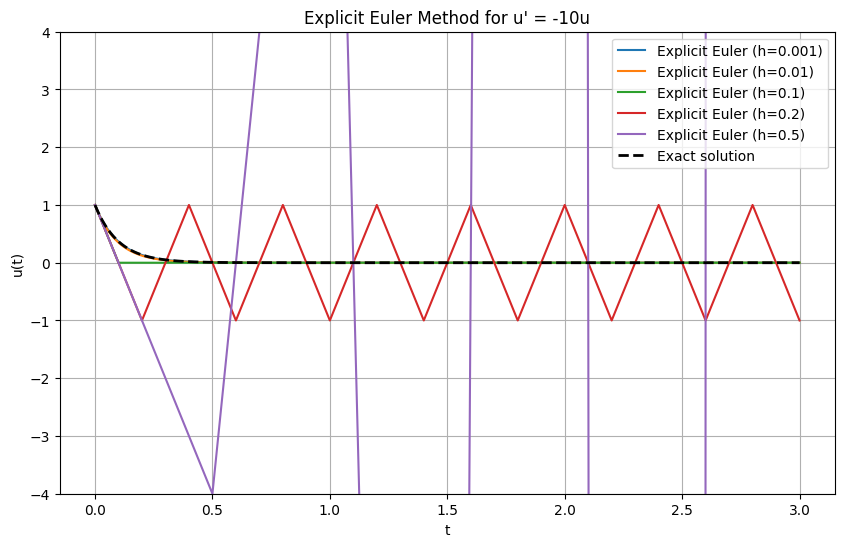

In [84]:
h_list = [0.001, 0.01, 0.1, 0.2, 0.5]
plt.figure(figsize=(10, 6))
plt.ylim(-4, 4)

for h in h_list:
    t, u = explicit_euler(h)
    plt.plot(t, u, label=f'Explicit Euler (h={h})')

# Exact solution
t_exact = np.linspace(0, 3, 1000)
u_exact = np.exp(-10 * t_exact)
plt.plot(t_exact, u_exact, 'k--', label='Exact solution', linewidth = 2.0)

plt.xlabel('t')
plt.ylabel('u(t)')
plt.legend()
plt.title("Explicit Euler Method for u' = -10u")
plt.grid(True)
plt.show()

(b) o Método de Euler Implícito, com $h = {0.001, 0.01, 0.1, 0.2, 0.5}$.

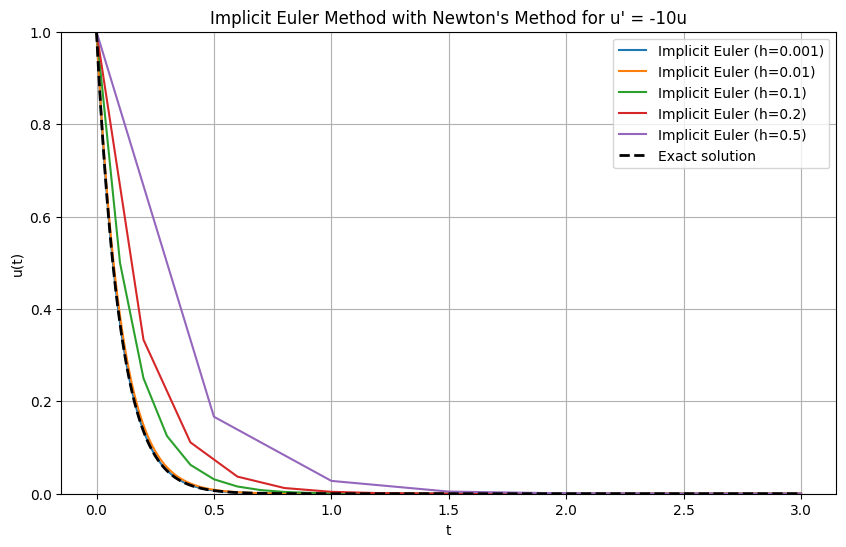

In [85]:
h_list = [0.001, 0.01, 0.1, 0.2, 0.5]
plt.figure(figsize=(10, 6))
plt.ylim(0, 1)

for h in h_list:
    t, u = implicit_euler_newton(h)
    plt.plot(t, u, label=f'Implicit Euler (h={h})')

# Exact solution
t_exact = np.linspace(0, 3, 1000)
u_exact = np.exp(-10 * t_exact)
plt.plot(t_exact, u_exact, 'k--', label='Exact solution', linewidth=2.0)

plt.xlabel('t')
plt.ylabel('u(t)')
plt.legend()
plt.title("Implicit Euler Method with Newton's Method for u' = -10u")
plt.grid(True)
plt.show()

(c) Plote um gráfico Log-Log mostrando a ordem de convergência dos métodos, através da norma $e_{\infty} = ||y(t_n) - y_n||_\infty$. Este gráfico deve apresentar o valor da norma obtida para diferentes valores de $h$, por exemplo $h = 0.1, 0.01, 0.001, 0.0001, 0.00001$. Dica: A solução exata do PVI $y(t) = e^{-10t} $.

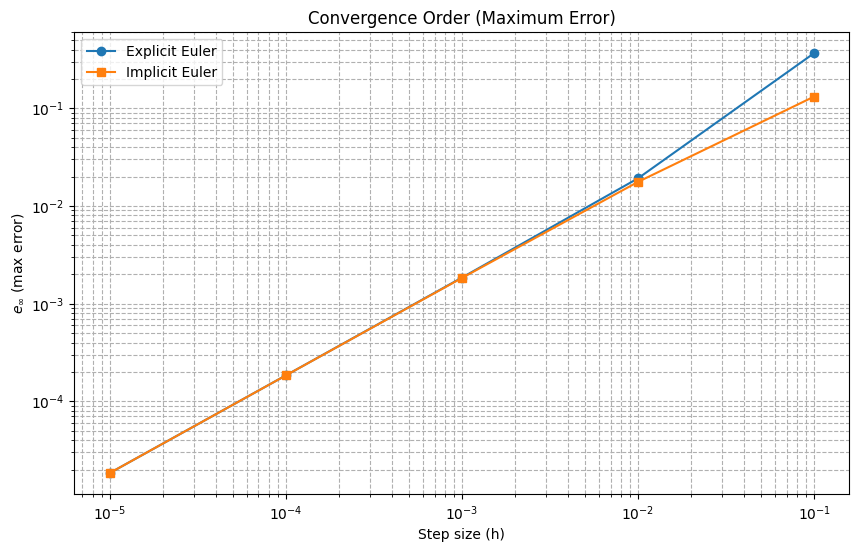

In [86]:
h_list = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
errors_explicit = []
errors_implicit = []
u_exact_func = lambda t: np.exp(-10 * t)

# Compute error
def compute_max_error(t, u_numeric, u_exact_func):
    u_exact = u_exact_func(t)
    return np.max(np.abs(u_exact - u_numeric))

for h in h_list:
    t_exp, u_exp = explicit_euler(h)
    err_exp = compute_max_error(t_exp, u_exp, u_exact_func)
    errors_explicit.append(err_exp)

    t_imp, u_imp = implicit_euler_newton(h)
    err_imp = compute_max_error(t_imp, u_imp, u_exact_func)
    errors_implicit.append(err_imp)

plt.figure(figsize=(10, 6))
plt.loglog(h_list, errors_explicit, 'o-', label='Explicit Euler')
plt.loglog(h_list, errors_implicit, 's-', label='Implicit Euler')
plt.xlabel('Step size (h)')
plt.ylabel(r'$e_\infty$ (max error)')
plt.title('Convergence Order (Maximum Error)')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()